# Lighting transfer across objects and views

The preceding probes establish that lighting is linearly recoverable within one object and view; linear OLAT pixels solve that problem essentially perfectly by construction. This experiment asks the stricter question:

> **What part of a lighting readout transfers to a new object, a new view, or both?**

Three complete objects—dolphin (4), hedgehog (5), and chicken (6)—share camera track A1–A6 and the same six measured axial lights. A single absolute probe is fitted on two objects and five views. Its coefficients, intercept, normalization, and regularization are then frozen. Target-domain predictions are evaluated either unchanged or after one constant correction measured at uniform illumination.

The representation rows are RayDer's 1024D pose-head-normalized token and 256D nuisance projection under independent and six-view-context inference, a frozen per-image DINOv3 token, and analytically mixed linear OLAT pixels.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/rayder-matplotlib")

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import Ridge

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "rayder").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks.common import (
    AXIS_LABELS, DINO_ID, load_dino, load_rayder, rayder_features,
    sample_mixtures, select_axis_lights, variance_weighted_r2,
)
from rayder.open_illumination import OpenIlluminationOLAT


/mnt/warm/dev/rayder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Fixed experimental construction

All domains use the same 500 weights, Dirichlet-family labels, mixture split, lamp indices, crop, and exposure. The outer test contains 25 mixtures from each family. Of the remaining 100 per family, 80 select and fit candidate regularization values and 20 validate them; after selection, the absolute probe is refitted on all 100.

Since the six lighting weights sum to one, they have five degrees of freedom. We represent them in an orthonormal five-dimensional basis centered at uniform illumination.
Let $w_0=\langle 1/6, \dots, 1/6\rangle$ and $H\in\mathbb R^{6\times5}$ with $H^\top H=I$ and $H^\top\mathbf1=0$,
then the target is:
$$q(w)=(w-w_0)^\top H.$$

The uniform condition is additional: it never participates in fitting or regularization selection.


In [2]:
DATA_ROOT = REPO_ROOT / "notebooks/data/openillumination-mini"
OBJECT_IDS, OBJECT_NAMES = (4, 5, 6), ("dolphin", "hedgehog", "chicken")
CAMERAS, RESOLUTION = ("A1", "A2", "A3", "A4", "A5", "A6"), 256
NUM_MIXTURES, SEED, EXPOSURE_EV = 500, 20260902, 3.0
RENDER_BATCH_SIZE, INDEPENDENT_BATCH_SIZE, CONTEXT_BATCH_SIZE = 2, 12, 2
MODEL_MASK, PIXEL_MASK, SUBTRACT_BACKGROUND = None, "object", False
RIDGE_ALPHAS = 10.0 ** torch.arange(-4, 5, dtype=torch.double)

datasets = [OpenIlluminationOLAT(DATA_ROOT, object_id, download_missing=False) for object_id in OBJECT_IDS]
light_directions, light_indices, selected_directions = select_axis_lights(datasets[0])
for dataset in datasets[1:]:
    directions, indices, selected = select_axis_lights(dataset)
    assert torch.equal(indices, light_indices) and torch.equal(directions, light_directions)

mixture_weights, mixture_family = sample_mixtures(NUM_MIXTURES, SEED)
families = mixture_family.unique(sorted=True)
reference_weight = torch.full((6,), 1 / 6)
all_weights = torch.cat([mixture_weights, reference_weight[None]])

def helmert_contrasts(size=6):
    basis = torch.zeros(size, size - 1)
    for column in range(size - 1):
        count = column + 1
        basis[:count, column] = 1 / math.sqrt(count * (count + 1))
        basis[count, column] = -count / math.sqrt(count * (count + 1))
    return basis

weight_basis = helmert_contrasts()
assert torch.allclose(weight_basis.T @ weight_basis, torch.eye(5), atol=1e-7)
assert torch.allclose(weight_basis.T @ torch.ones(6), torch.zeros(5), atol=1e-7)
weight_coordinates = (mixture_weights - reference_weight) @ weight_basis

generator = torch.Generator().manual_seed(SEED + 1)
fit_parts, validation_parts, test_parts = [], [], []
for alpha in families:
    indices = torch.where(mixture_family == alpha)[0]
    indices = indices[torch.randperm(len(indices), generator=generator)]
    fit_parts.append(indices[:80])
    validation_parts.append(indices[80:100])
    test_parts.append(indices[100:125])
fit_indices = torch.cat(fit_parts)
validation_indices = torch.cat(validation_parts)
train_indices = torch.cat([fit_indices, validation_indices])
test_indices = torch.cat(test_parts)

print("objects:", dict(zip(OBJECT_IDS, OBJECT_NAMES)))
print("cameras:", CAMERAS)
for label, index, direction in zip(AXIS_LABELS, light_indices, selected_directions):
    print(f"{label:>2}: light {index.item():3d}, direction={direction.tolist()}")
print(f"mixtures: fit={len(fit_indices)}, validation={len(validation_indices)}, test={len(test_indices)}, reference=uniform")


objects: {4: 'dolphin', 5: 'hedgehog', 6: 'chicken'}
cameras: ('A1', 'A2', 'A3', 'A4', 'A5', 'A6')
+x: light  82, direction=[0.9949327707290649, 0.012538393028080463, -0.09975770115852356]
-x: light  77, direction=[-0.9934996366500854, 0.055403318256139755, 0.09944342076778412]
+y: light 139, direction=[0.32102105021476746, 0.8998042941093445, 0.2954619228839874]
-y: light   0, direction=[0.002798927715048194, -0.987995445728302, 0.15445780754089355]
+z: light  62, direction=[-0.11902597546577454, 0.013896279968321323, 0.9927939176559448]
-z: light  86, direction=[0.13224151730537415, 0.05854164436459541, -0.9894872903823853]
mixtures: fit=320, validation=80, test=100, reference=uniform


/home/user/.pyenv/versions/3.13.7/lib/python3.13/contextlib.py:141: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  return next(self.gen)


## Domains and inputs

Rows below differ only in illumination; columns differ only in object. The uniform reference is well lit and symmetric. The second row is an actual concentrated mixture from the evaluation distribution. Camera A3 is shown only for orientation—the experiment uses the complete A1–A6 track.


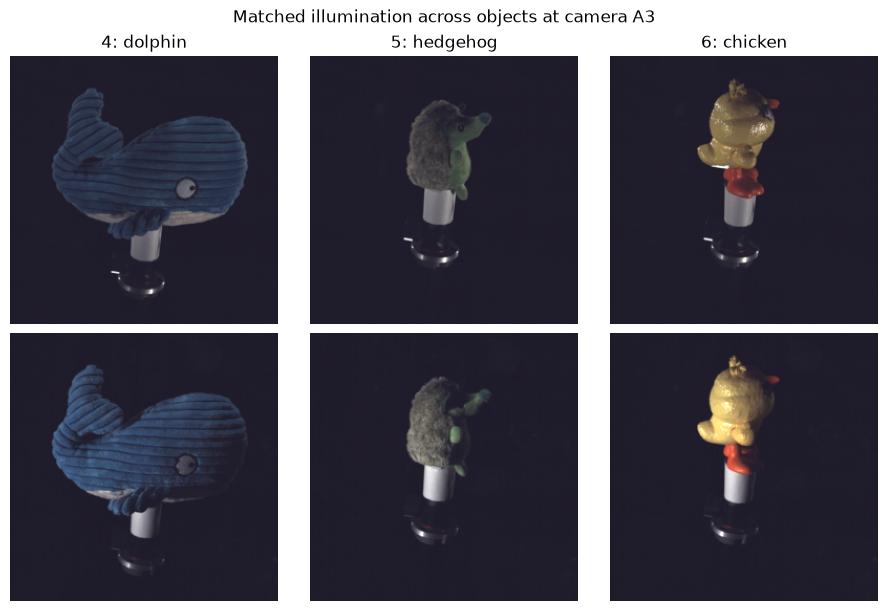

In [3]:
radius = torch.linalg.vector_norm(mixture_weights - reference_weight, dim=1)
preview_index = (radius - radius.quantile(0.9)).abs().argmin()
preview_weights = torch.stack([reference_weight, mixture_weights[preview_index]])
fig, axes = plt.subplots(2, len(datasets), figsize=(9, 6), constrained_layout=True)
for column, (dataset, object_id, object_name) in enumerate(zip(datasets, OBJECT_IDS, OBJECT_NAMES)):
    images = dataset.render_weight_batch(
        preview_weights.numpy(), cameras=["A3"], light_indices=light_indices.numpy(), size=RESOLUTION,
        center_crop=True, exposure_ev=EXPOSURE_EV, mask=MODEL_MASK, subtract_background=SUBTRACT_BACKGROUND,
    )[:, 0]
    for row, image in enumerate(images):
        axes[row, column].imshow(image); axes[row, column].axis("off")
        axes[row, column].set_title(f"{object_id}: {object_name}" if row == 0 else "")
axes[0, 0].set_ylabel("uniform reference")
axes[1, 0].set_ylabel(f"sampled mixture\nmax w={mixture_weights[preview_index].max():.2f}")
fig.suptitle("Matched illumination across objects at camera A3")
plt.show()


## Paired feature extraction

Every rendered `(mixture, view)` batch is reused for all feature axes. Independent RayDer and DINOv3 flatten the view dimension into one-image inputs. Contextual RayDer preserves A1–A6 and fixes temporal rank to camera identity. The final uniform-light sample supplies one reference feature for each object–view domain.

Backbones receive the same unmasked, centered, exposure-adjusted sRGB crop used by the earlier notebooks. DINOv3 is a generic per-image visual reference, not a context-conditioned model or an appearance oracle.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp = dict(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == "cuda")
rayder_model = load_rayder(device)
dino_model, dino_mean, dino_std = load_dino(device, DINO_ID)
view_indices = torch.arange(len(CAMERAS))
fixed_temporal_ranks = view_indices.clone()
print(f"device={device}; RayDer token={rayder_model.width}D, nuisance={rayder_model.d_dynamic_state}D; DINO={dino_model.config.hidden_size}D")

@torch.no_grad()
def infer_independent(images):
    flat = torch.from_numpy(images).flatten(0, 1)
    token_parts, nuisance_parts, dino_parts = [], [], []
    for start in range(0, len(flat), INDEPENDENT_BATCH_SIZE):
        image_batch = flat[start : start + INDEPENDENT_BATCH_SIZE].to(device)
        with torch.autocast(**amp):
            _, tokens, nuisance = rayder_features(rayder_model, image_batch[:, None].mul(2).sub(1))
            dino = dino_model(pixel_values=(image_batch.permute(0, 3, 1, 2) - dino_mean) / dino_std).pooler_output
        token_parts.append(tokens[:, 0].float().cpu())
        nuisance_parts.append(nuisance[:, 0].float().cpu())
        dino_parts.append(dino.float().cpu())
    shape = (len(images), len(CAMERAS), -1)
    return {
        "RayDer token · independent": torch.cat(token_parts).reshape(shape),
        "RayDer nuisance · independent": torch.cat(nuisance_parts).reshape(shape),
        "DINOv3 · per image": torch.cat(dino_parts).reshape(shape),
    }

@torch.no_grad()
def infer_context(images):
    parts = {"RayDer token · context": [], "RayDer nuisance · context": []}
    image_tensor = torch.from_numpy(images)
    for start in range(0, len(image_tensor), CONTEXT_BATCH_SIZE):
        image_batch = image_tensor[start : start + CONTEXT_BATCH_SIZE].to(device)
        with torch.autocast(**amp):
            _, tokens, nuisance = rayder_features(
                rayder_model, image_batch.mul(2).sub(1), fixed_temporal_ranks.to(device),
            )
        parts["RayDer token · context"].append(tokens.float().cpu())
        parts["RayDer nuisance · context"].append(nuisance.float().cpu())
    return {name: torch.cat(values) for name, values in parts.items()}


Loading weights: 100%|██████████| 415/415 [00:02<00:00, 160.76it/s]


device=cuda; RayDer token=1024D, nuisance=256D; DINO=1024D


In [5]:
object_features = []
for object_number, (object_id, dataset) in enumerate(zip(OBJECT_IDS, datasets), 1):
    parts = {name: [] for name in (
        "RayDer token · independent", "RayDer token · context",
        "RayDer nuisance · independent", "RayDer nuisance · context",
        "DINOv3 · per image",
    )}
    batches = dataset.iter_render_weight_batches(
        all_weights.numpy(), cameras=CAMERAS, light_indices=light_indices.numpy(), batch_size=RENDER_BATCH_SIZE,
        size=RESOLUTION, center_crop=True, exposure_ev=EXPOSURE_EV, mask=MODEL_MASK,
        subtract_background=SUBTRACT_BACKGROUND,
    )
    num_batches = math.ceil(len(all_weights) / RENDER_BATCH_SIZE)
    for batch_index, images in enumerate(batches, 1):
        outputs = infer_independent(images) | infer_context(images)
        for name in parts: parts[name].append(outputs[name])
        if batch_index == 1 or batch_index % 25 == 0 or batch_index == num_batches:
            print(f"object {object_id} ({object_number}/{len(OBJECT_IDS)}), batch {batch_index:3d}/{num_batches}")
    object_features.append({name: torch.cat(values).transpose(0, 1) for name, values in parts.items()})

representation_names = tuple(object_features[0])
all_features = {name: torch.stack([values[name] for values in object_features]) for name in representation_names}
features = {name: values[:, :, :NUM_MIXTURES] for name, values in all_features.items()}
reference_features = {name: values[:, :, NUM_MIXTURES] for name, values in all_features.items()}
print({name: tuple(values.shape) for name, values in features.items()})


object 4 (1/3), batch   1/251
object 4 (1/3), batch  25/251
object 4 (1/3), batch  50/251
object 4 (1/3), batch  75/251
object 4 (1/3), batch 100/251
object 4 (1/3), batch 125/251
object 4 (1/3), batch 150/251
object 4 (1/3), batch 175/251
object 4 (1/3), batch 200/251
object 4 (1/3), batch 225/251
object 4 (1/3), batch 250/251


W0915 15:31:49.623000 1754647 .venv/lib/python3.13/site-packages/torch/_dynamo/convert_frame.py:2008] [3/8] torch._dynamo hit config.recompile_limit (8)
W0915 15:31:49.623000 1754647 .venv/lib/python3.13/site-packages/torch/_dynamo/convert_frame.py:2008] [3/8]    function: 'forward' (/mnt/warm/dev/rayder/rayder/model.py:615)
W0915 15:31:49.623000 1754647 .venv/lib/python3.13/site-packages/torch/_dynamo/convert_frame.py:2008] [3/8]    last reason: 3/7: tensor 'x' size mismatch at index 2. expected 64, actual 32
W0915 15:31:49.623000 1754647 .venv/lib/python3.13/site-packages/torch/_dynamo/convert_frame.py:2008] [3/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0915 15:31:49.623000 1754647 .venv/lib/python3.13/site-packages/torch/_dynamo/convert_frame.py:2008] [3/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


object 4 (1/3), batch 251/251
object 5 (2/3), batch   1/251
object 5 (2/3), batch  25/251
object 5 (2/3), batch  50/251
object 5 (2/3), batch  75/251
object 5 (2/3), batch 100/251
object 5 (2/3), batch 125/251
object 5 (2/3), batch 150/251
object 5 (2/3), batch 175/251
object 5 (2/3), batch 200/251
object 5 (2/3), batch 225/251
object 5 (2/3), batch 250/251
object 5 (2/3), batch 251/251
object 6 (3/3), batch   1/251
object 6 (3/3), batch  25/251
object 6 (3/3), batch  50/251
object 6 (3/3), batch  75/251
object 6 (3/3), batch 100/251
object 6 (3/3), batch 125/251
object 6 (3/3), batch 150/251
object 6 (3/3), batch 175/251
object 6 (3/3), batch 200/251
object 6 (3/3), batch 225/251
object 6 (3/3), batch 250/251
object 6 (3/3), batch 251/251
{'RayDer token · independent': (3, 6, 500, 1024), 'RayDer token · context': (3, 6, 500, 1024), 'RayDer nuisance · independent': (3, 6, 500, 256), 'RayDer nuisance · context': (3, 6, 500, 256), 'DINOv3 · per image': (3, 6, 500, 1024)}


## Exact linear-pixel representation

For object $o$ and view $v$, let $B_{ov}\in\mathbb R^{6\times D}$ contain the six flattened, object-masked linear-RGB OLAT images. Their analytic mixture is

$$x_{ov}(w)=w^\top B_{ov}.$$

The $108\times108$ Gram matrix of all object--view--lamp bases defines an exact finite coordinate system for $x/\sqrt D$. Factorizing that small Gram matrix is algebraically equivalent to fitting ridge on the flattened pixels; no $D$-dimensional coefficient matrix or mixture-image tensor is constructed. These pixels are exposure-scaled linear OLAT mixtures before display encoding and clipping, so they are an image-formation reference rather than the exact sRGB backbone input.


In [6]:
pixel_bases = []
for object_id, dataset in zip(OBJECT_IDS, datasets):
    basis_srgb = torch.tensor(dataset.render_weight_batch(
        torch.eye(6).numpy(), cameras=CAMERAS, light_indices=light_indices.numpy(), size=RESOLUTION,
        center_crop=True, exposure_ev=0, mask=PIXEL_MASK, subtract_background=SUBTRACT_BACKGROUND,
    ))
    basis_linear = torch.where(
        basis_srgb <= 0.04045, basis_srgb / 12.92, ((basis_srgb + 0.055) / 1.055).pow(2.4),
    )
    pixel_bases.append((basis_linear * 2**EXPOSURE_EV).permute(1, 0, 2, 3, 4).flatten(2))
pixel_bases = torch.stack(pixel_bases)  # (object, view, light, pixel channel)
flat_bases = pixel_bases.flatten(0, 2).float()
pixel_gram = (flat_bases @ flat_bases.T).double() / flat_bases.shape[1]
eigenvalues, eigenvectors = torch.linalg.eigh(pixel_gram)
retained = eigenvalues > eigenvalues.max() * 1e-10
pixel_factor = eigenvectors[:, retained] * eigenvalues[retained].sqrt()

pixel_all_features = []
for object_index in range(len(OBJECT_IDS)):
    view_features = []
    for view in range(len(CAMERAS)):
        start = (object_index * len(CAMERAS) + view) * 6
        view_features.append(all_weights.double() @ pixel_factor[start : start + 6])
    pixel_all_features.append(torch.stack(view_features))
pixel_all_features = torch.stack(pixel_all_features).float()
features["linear OLAT pixels"] = pixel_all_features[:, :, :NUM_MIXTURES]
reference_features["linear OLAT pixels"] = pixel_all_features[:, :, NUM_MIXTURES]
representation_names = tuple(features)
print(f"pixel channels={flat_bases.shape[1]:,}; exact OLAT-span dimension={retained.sum().item()}")


pixel channels=196,608; exact OLAT-span dimension=108


## Absolute transfer and frozen-probe reference calibration

For held-out object $o^*$ and view $v^*$, the absolute probe is fitted only on $o\ne o^*$, $v\ne v^*$, and the training mixtures:

$$f(z)=b+W^\top z.$$

Feature centering and a single RMS scale are estimated from source fitting data. Regularization is selected on source validation mixtures, grouped across all source domains, then the same absolute probe is refitted on all source training mixtures. The reference never influences fitting or selection.

At evaluation, the absolute prediction is $f(z_{ov}(w))$. Frozen-probe calibration changes only its target-domain constant:

$$f^{anchor}_{ov}(w)=f(z_{ov}(w))-f(z_{ov}(w_0)).$$

Thus $b$, $W$, normalization, and regularization are identical in both columns. This is one-reference output calibration, not a separately trained anchored probe.

Each fold is evaluated on four held-out-mixture quadrants:

| objects | views | interpretation |
|---|---|---|
| source | source | mixture-only control |
| held out | source | object transfer |
| source | held out | view transfer |
| held out | held out | joint object + view transfer |

For contextual features, all six images participate in feature extraction even when one token is excluded from probe fitting. “View transfer” therefore describes the learned readout coordinates, not an extractor that never observed that image.


In [7]:
def stack_domains(values, objects, views, mixtures):
    return torch.cat([values[object_index, view, mixtures] for object_index in objects for view in views])

def repeated_targets(mixtures, num_domains):
    return weight_coordinates[mixtures].repeat(num_domains, 1)

def normalization(values):
    mean = values.mean(0)
    scale = torch.linalg.vector_norm(values - mean, dim=1).square().mean().sqrt().clamp_min(1e-8)
    return mean, scale

def fit_absolute_probe(fit_x, fit_y, validation_x, validation_y, train_x, train_y):
    fit_mean, fit_scale = normalization(fit_x)
    fit_xn, validation_xn = (fit_x - fit_mean) / fit_scale, (validation_x - fit_mean) / fit_scale
    best_alpha, best_loss = None, float("inf")
    for alpha in RIDGE_ALPHAS:
        candidate = Ridge(alpha=float(alpha), solver="lsqr", tol=1e-6).fit(fit_xn.numpy(), fit_y.numpy())
        prediction = torch.from_numpy(candidate.predict(validation_xn.numpy()))
        loss = (prediction - validation_y).square().mean().item()
        if loss <= best_loss:
            best_alpha, best_loss = float(alpha), loss
    train_mean, train_scale = normalization(train_x)
    model = Ridge(alpha=best_alpha, solver="lsqr", tol=1e-6).fit(
        ((train_x - train_mean) / train_scale).numpy(), train_y.numpy(),
    )
    return model, train_mean, train_scale, best_alpha

def predict_absolute(probe, values):
    model, mean, scale, _ = probe
    return torch.from_numpy(model.predict(((values - mean) / scale).numpy())).to(values)

def evaluate_domains(probe, values, references, objects, views, mixtures, anchored):
    predictions, corrections = [], []
    for object_index in objects:
        for view in views:
            prediction = predict_absolute(probe, values[object_index, view, mixtures])
            correction = -predict_absolute(
                probe, references[object_index, view, None],
            ).squeeze(0)
            predictions.append(prediction + correction if anchored else prediction)
            corrections.append(correction)
    return torch.cat(predictions), torch.stack(corrections)

def score_predictions(prediction, mixtures, num_domains):
    target_q = repeated_targets(mixtures, num_domains).to(prediction)
    target_weights = mixture_weights[mixtures].repeat(num_domains, 1).to(prediction)
    predicted_weights = reference_weight.to(prediction) + prediction @ weight_basis.T.to(prediction)
    return variance_weighted_r2(target_q, prediction), (target_weights - predicted_weights).abs().mean()


In [8]:
quadrants = ("mixture only", "object", "view", "object + view")
calibrations = ("absolute", "reference-anchored")
shape = (len(OBJECT_IDS), len(CAMERAS))
r2_results = {name: {mode: {quadrant: torch.empty(shape) for quadrant in quadrants} for mode in calibrations} for name in representation_names}
mae_results = {name: {mode: {quadrant: torch.empty(shape) for quadrant in quadrants} for mode in calibrations} for name in representation_names}
selected_alphas = {name: torch.empty(shape) for name in representation_names}
correction_norms = {name: torch.empty(shape) for name in representation_names}
joint_predictions = {name: {mode: torch.empty(*shape, len(test_indices), 5) for mode in calibrations} for name in representation_names}

for held_object in range(len(OBJECT_IDS)):
    source_objects = [index for index in range(len(OBJECT_IDS)) if index != held_object]
    for held_view in range(len(CAMERAS)):
        source_views = [index for index in range(len(CAMERAS)) if index != held_view]
        evaluations = {
            "mixture only": (source_objects, source_views),
            "object": ([held_object], source_views),
            "view": (source_objects, [held_view]),
            "object + view": ([held_object], [held_view]),
        }
        for name in representation_names:
            values, references = features[name], reference_features[name]
            fit_x = stack_domains(values, source_objects, source_views, fit_indices)
            validation_x = stack_domains(values, source_objects, source_views, validation_indices)
            train_x = stack_domains(values, source_objects, source_views, train_indices)
            fit_y = repeated_targets(fit_indices, len(source_objects) * len(source_views))
            validation_y = repeated_targets(validation_indices, len(source_objects) * len(source_views))
            train_y = repeated_targets(train_indices, len(source_objects) * len(source_views))
            probe = fit_absolute_probe(fit_x, fit_y, validation_x, validation_y, train_x, train_y)
            selected_alphas[name][held_object, held_view] = probe[-1]
            for mode in calibrations:
                anchored = mode == "reference-anchored"
                for quadrant, (objects, views) in evaluations.items():
                    prediction, corrections = evaluate_domains(
                        probe, values, references, objects, views, test_indices, anchored,
                    )
                    r2, mae = score_predictions(prediction, test_indices, len(objects) * len(views))
                    r2_results[name][mode][quadrant][held_object, held_view] = r2
                    mae_results[name][mode][quadrant][held_object, held_view] = mae
                    if quadrant == "object + view":
                        joint_predictions[name][mode][held_object, held_view] = prediction
                        if anchored: correction_norms[name][held_object, held_view] = corrections[0].norm()
        print(f"completed transfer fold: object {OBJECT_IDS[held_object]}, view {CAMERAS[held_view]}")


completed transfer fold: object 4, view A1
completed transfer fold: object 4, view A2
completed transfer fold: object 4, view A3
completed transfer fold: object 4, view A4
completed transfer fold: object 4, view A5
completed transfer fold: object 4, view A6
completed transfer fold: object 5, view A1
completed transfer fold: object 5, view A2
completed transfer fold: object 5, view A3
completed transfer fold: object 5, view A4
completed transfer fold: object 5, view A5
completed transfer fold: object 5, view A6
completed transfer fold: object 6, view A1
completed transfer fold: object 6, view A2
completed transfer fold: object 6, view A3
completed transfer fold: object 6, view A4
completed transfer fold: object 6, view A5
completed transfer fold: object 6, view A6


## 1. Which boundary breaks the readout?

The first two panels show mean absolute and reference-anchored $R^2$ over all 18 held-out object–view folds. The third is their paired difference. A calibration gain indicates a target-domain prediction offset that the frozen source readout exposes at uniform illumination; it does not demonstrate improved readout directions.


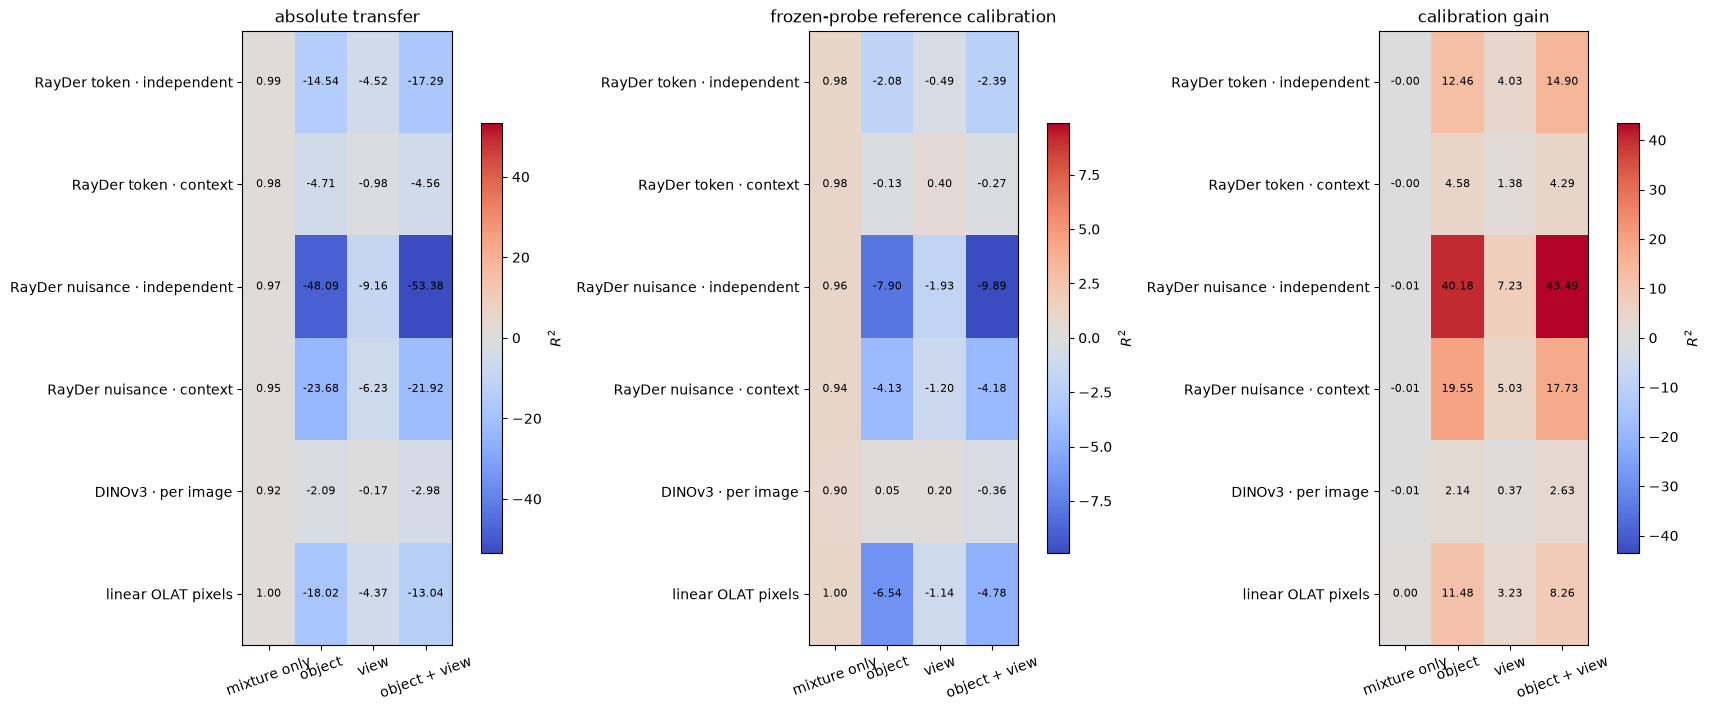

In [9]:
aggregate_r2 = {
    name: {
        mode: torch.tensor([r2_results[name][mode][quadrant].mean() for quadrant in quadrants])
        for mode in calibrations
    }
    for name in representation_names
}
absolute_matrix = torch.stack([aggregate_r2[name]["absolute"] for name in representation_names])
anchored_matrix = torch.stack([aggregate_r2[name]["reference-anchored"] for name in representation_names])
gain_matrix = anchored_matrix - absolute_matrix

fig, axes = plt.subplots(1, 3, figsize=(17, 7), constrained_layout=True)
for ax, matrix, title in zip(
    axes, (absolute_matrix, anchored_matrix, gain_matrix),
    ("absolute transfer", "frozen-probe reference calibration", "calibration gain"),
):
    bound = max(1.0, matrix.abs().max().item()) if title != "calibration gain" else matrix.abs().max().clamp_min(0.1).item()
    image = ax.imshow(matrix, aspect="auto", cmap="coolwarm", vmin=-bound, vmax=bound)
    for row in range(len(representation_names)):
        for column in range(len(quadrants)):
            ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center", fontsize=8)
    ax.set(title=title, xticks=range(len(quadrants)), xticklabels=quadrants,
           yticks=range(len(representation_names)), yticklabels=representation_names)
    ax.tick_params(axis="x", rotation=20)
    fig.colorbar(image, ax=ax, shrink=0.7, label=r"$R^2$")
plt.show()


## 2. Joint object-and-view transfer by target domain

Aggregate scores can hide one object or camera that defines the result. Each row below retains all 18 strict target domains. Absolute and calibrated panels share their representation-specific color range; the gain panel is centered at zero.


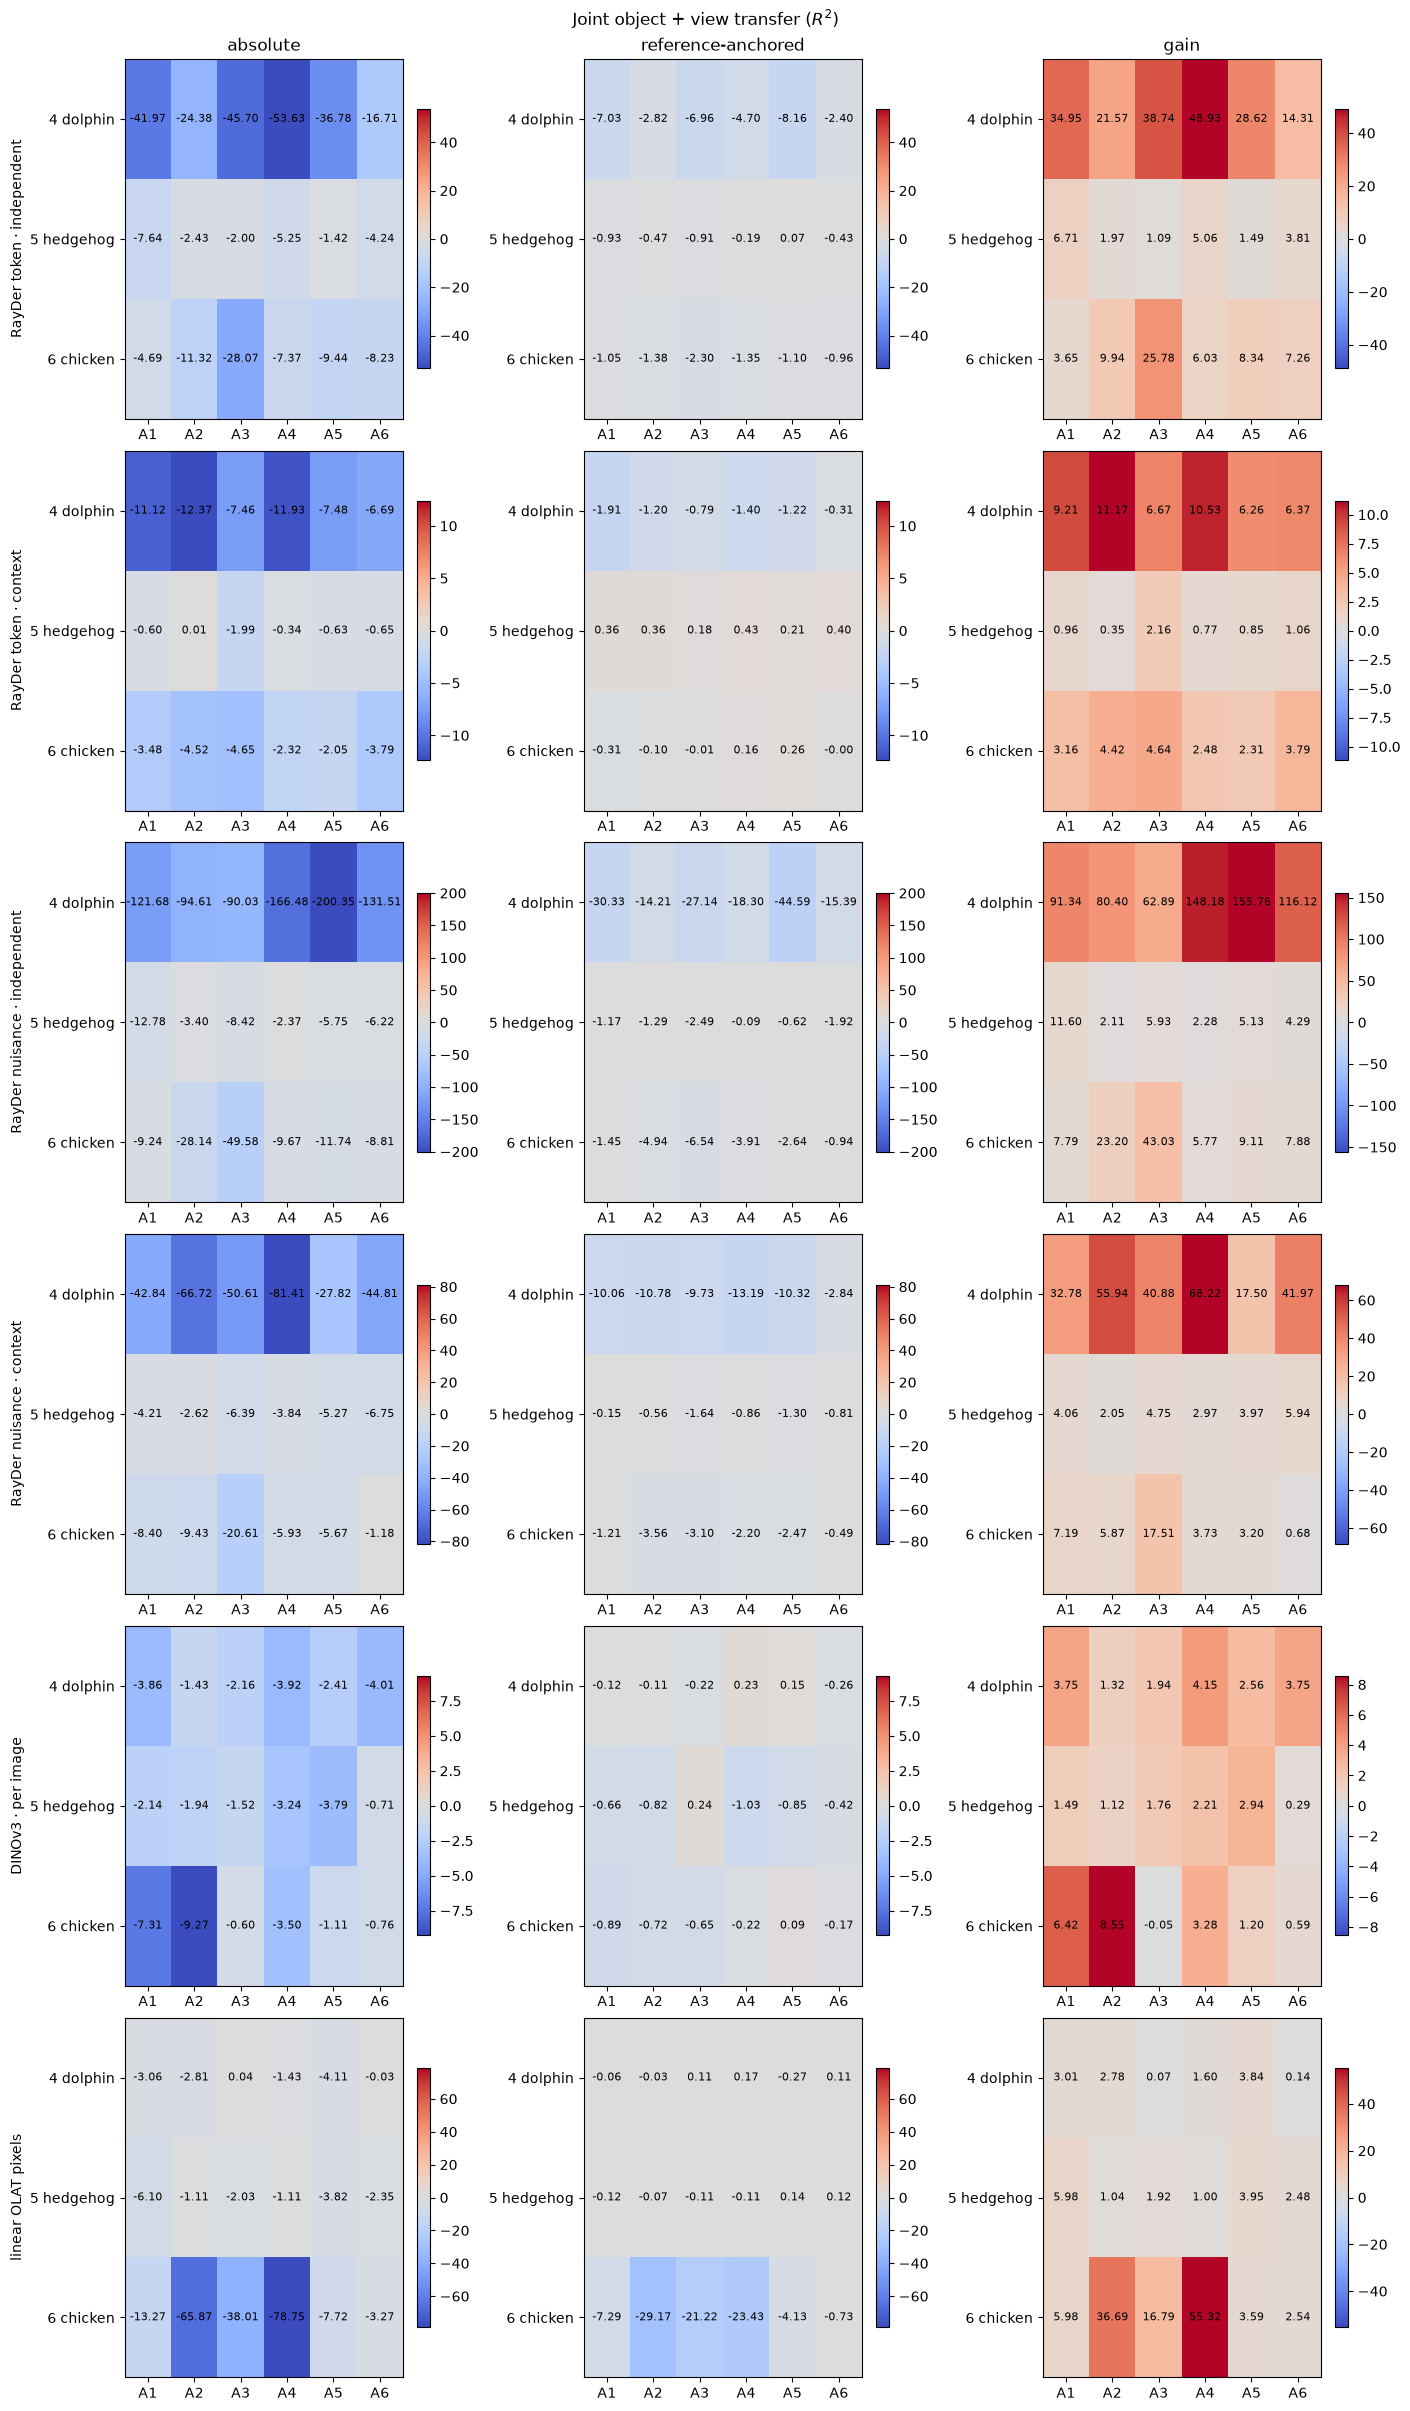

In [10]:
object_labels = [f"{object_id} {name}" for object_id, name in zip(OBJECT_IDS, OBJECT_NAMES)]
fig, axes = plt.subplots(len(representation_names), 3, figsize=(14, 4 * len(representation_names)), constrained_layout=True)
for row, name in enumerate(representation_names):
    absolute = r2_results[name]["absolute"]["object + view"]
    anchored = r2_results[name]["reference-anchored"]["object + view"]
    matrices = (absolute, anchored, anchored - absolute)
    absolute_bound = max(1.0, absolute.abs().max().item(), anchored.abs().max().item())
    gain_bound = (anchored - absolute).abs().max().clamp_min(0.1).item()
    for column, (matrix, title) in enumerate(zip(matrices, ("absolute", "reference-anchored", "gain"))):
        bound = gain_bound if title == "gain" else absolute_bound
        image = axes[row, column].imshow(matrix, cmap="coolwarm", vmin=-bound, vmax=bound, aspect="auto")
        for object_index in range(len(OBJECT_IDS)):
            for view in range(len(CAMERAS)):
                axes[row, column].text(view, object_index, f"{matrix[object_index, view]:.2f}", ha="center", va="center", fontsize=8)
        axes[row, column].set(xticks=range(len(CAMERAS)), xticklabels=CAMERAS,
                              yticks=range(len(OBJECT_IDS)), yticklabels=object_labels,
                              title=title if row == 0 else "")
        if column == 0: axes[row, column].set_ylabel(name)
        fig.colorbar(image, ax=axes[row, column], shrink=0.72)
fig.suptitle(r"Joint object + view transfer ($R^2$)")
plt.show()


## 3. What does the reference correction remove?

The correction vector

$$c_{ov}=-f(z_{ov}(w_0))$$

is the target domain's predicted displacement of uniform illumination. Its norm measures the constant output error removed by calibration. A large correction need not improve performance: calibration helps only when that reference error persists approximately unchanged across other illuminations.


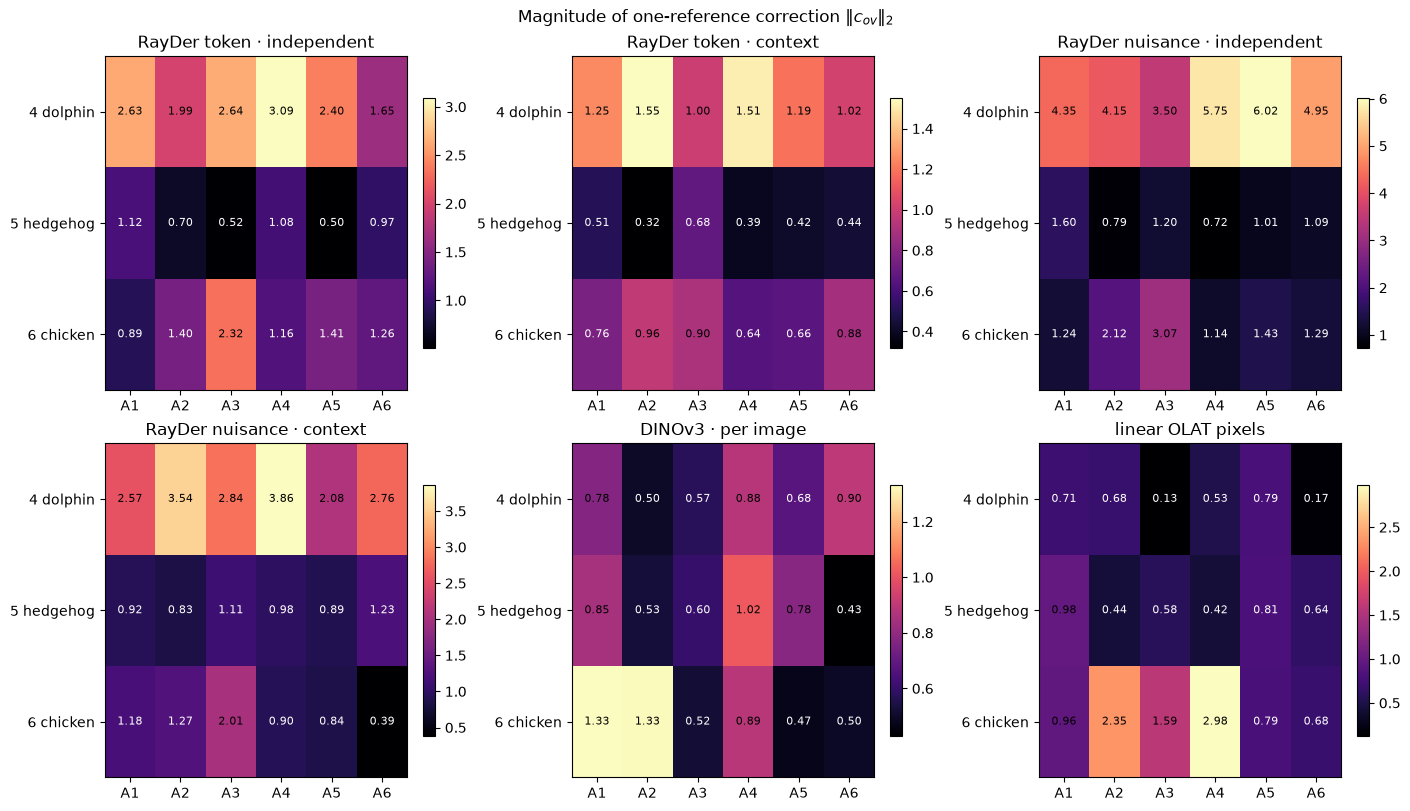

selected absolute-probe ridge α (median [min, max])
RayDer token · independent      0.0001 [0.0001, 0.0001]
RayDer token · context          0.0001 [0.0001, 0.0001]
RayDer nuisance · independent   0.0001 [0.0001, 0.001]
RayDer nuisance · context       0.0001 [0.0001, 0.0001]
DINOv3 · per image              0.01 [0.01, 0.01]
linear OLAT pixels              0.0001 [0.0001, 0.0001]


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for ax, name in zip(axes.flat, representation_names):
    matrix = correction_norms[name]
    image = ax.imshow(matrix, cmap="magma", aspect="auto")
    mat_mean = matrix.mean()
    for object_index in range(len(OBJECT_IDS)):
        for view in range(len(CAMERAS)):
            ax.text(view, object_index, f"{matrix[object_index, view]:.2f}", ha="center", va="center", color="white" if matrix[object_index, view] < mat_mean else "black", fontsize=8)
    ax.set(title=name, xticks=range(len(CAMERAS)), xticklabels=CAMERAS,
           yticks=range(len(OBJECT_IDS)), yticklabels=object_labels)
    fig.colorbar(image, ax=ax, shrink=0.75)
fig.suptitle(r"Magnitude of one-reference correction $\|c_{ov}\|_2$")
plt.show()

print("selected absolute-probe ridge α (median [min, max])")
for name, values in selected_alphas.items():
    print(f"{name:<31} {values.median():.3g} [{values.min():.3g}, {values.max():.3g}]")


## 4. Does transfer depend on lighting concentration?

The strict object-plus-view predictions are rescored within each Dirichlet family. This preserves the same fitted probe and calibration; no family-specific model or regularization is introduced. Sparse families emphasize individual lamp responses, while diffuse families emphasize subtler redistribution around broad illumination.


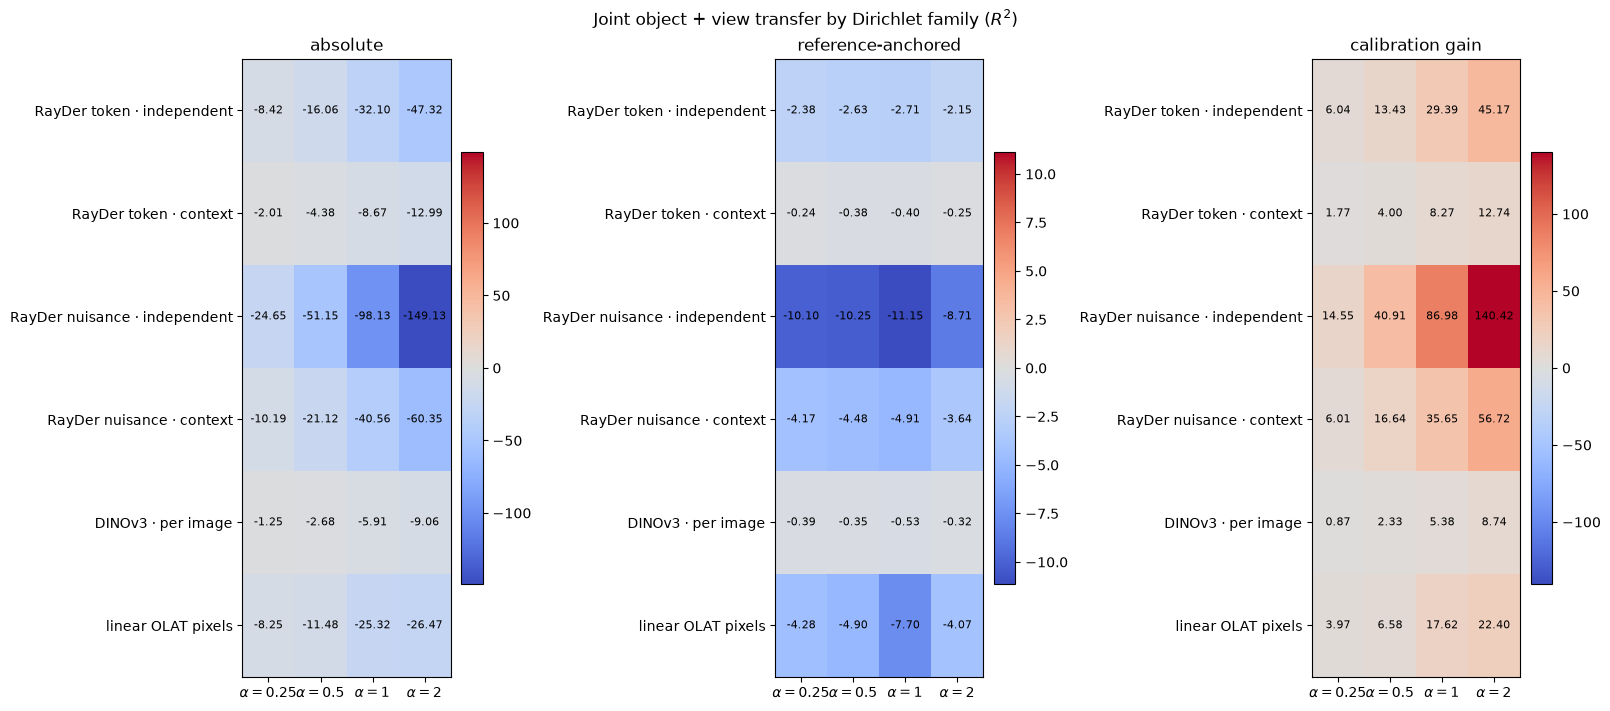

In [12]:
test_families = mixture_family[test_indices]
family_results = {name: {mode: [] for mode in calibrations} for name in representation_names}
for name in representation_names:
    for mode in calibrations:
        predictions = joint_predictions[name][mode]
        for alpha in families:
            selected = test_families == alpha
            prediction = predictions[:, :, selected].flatten(0, 2)
            target = weight_coordinates[test_indices][selected].repeat(len(OBJECT_IDS) * len(CAMERAS), 1)
            family_results[name][mode].append(variance_weighted_r2(target.to(prediction), prediction))
        family_results[name][mode] = torch.stack(family_results[name][mode])

absolute_family = torch.stack([family_results[name]["absolute"] for name in representation_names])
anchored_family = torch.stack([family_results[name]["reference-anchored"] for name in representation_names])
fig, axes = plt.subplots(1, 3, figsize=(16, 7), constrained_layout=True)
for ax, matrix, title in zip(
    axes, (absolute_family, anchored_family, anchored_family - absolute_family),
    ("absolute", "reference-anchored", "calibration gain"),
):
    bound = max(1.0, matrix.abs().max().item()) if title != "calibration gain" else matrix.abs().max().clamp_min(0.1).item()
    image = ax.imshow(matrix, aspect="auto", cmap="coolwarm", vmin=-bound, vmax=bound)
    for row in range(len(representation_names)):
        for column in range(len(families)):
            ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center", fontsize=8)
    ax.set(title=title, xticks=range(len(families)), xticklabels=[fr"$\alpha={value:g}$" for value in families],
           yticks=range(len(representation_names)), yticklabels=representation_names)
    fig.colorbar(image, ax=ax, shrink=0.7)
fig.suptitle(r"Joint object + view transfer by Dirichlet family ($R^2$)")
plt.show()


## Compact result table

The report-level comparison is the strict joint-transfer column. Values below average the 18 target domains equally. Weight MAE is computed after the unconstrained contrast prediction is mapped back to six lamp weights; predictions are not projected onto the simplex.


In [13]:
header = f"{'representation':<31} {'absolute R2':>12} {'anchored R2':>13} {'gain':>9} {'absolute MAE':>14} {'anchored MAE':>14} {'|correction|':>14}"
print(header); print("-" * len(header))
for name in representation_names:
    absolute_r2 = r2_results[name]["absolute"]["object + view"].mean()
    anchored_r2 = r2_results[name]["reference-anchored"]["object + view"].mean()
    absolute_mae = mae_results[name]["absolute"]["object + view"].mean()
    anchored_mae = mae_results[name]["reference-anchored"]["object + view"].mean()
    print(f"{name:<31} {absolute_r2:>12.3f} {anchored_r2:>13.3f} {(anchored_r2 - absolute_r2):>9.3f} "
          f"{absolute_mae:>14.4f} {anchored_mae:>14.4f} {correction_norms[name].mean():>14.3f}")


representation                   absolute R2   anchored R2      gain   absolute MAE   anchored MAE   |correction|
-----------------------------------------------------------------------------------------------------------------
RayDer token · independent           -17.293        -2.391    14.902         0.4995         0.2087          1.541
RayDer token · context                -4.559        -0.271     4.288         0.2950         0.1330          0.838
RayDer nuisance · independent        -53.376        -9.888    43.489         0.7901         0.3302          2.525
RayDer nuisance · context            -21.916        -4.182    17.734         0.5481         0.2522          1.678
DINOv3 · per image                    -2.982        -0.357     2.625         0.2646         0.1404          0.752
linear OLAT pixels                   -13.045        -4.782     8.262         0.3322         0.2043          0.902


## Separately fitted anchored probe

The frozen-probe calibration above asks whether a target-domain constant fixes an absolute source readout. As a complementary experiment, we now anchor every representation before probe selection and fitting:

$$\tilde z_{ov}(w)=z_{ov}(w)-z_{ov}(w_0).$$

A new ridge probe, including its normalization and selected regularization, is fitted only on anchored source-domain features and evaluated directly on anchored target-domain features. This still uses the uniform reference from each evaluation domain, but unlike frozen-probe calibration it allows the fitted readout directions to change.


In [14]:
refit_anchored_r2 = {name: {quadrant: torch.empty(shape) for quadrant in quadrants} for name in representation_names}
refit_anchored_mae = {name: {quadrant: torch.empty(shape) for quadrant in quadrants} for name in representation_names}
refit_anchored_alphas = {name: torch.empty(shape) for name in representation_names}

for held_object in range(len(OBJECT_IDS)):
    source_objects = [index for index in range(len(OBJECT_IDS)) if index != held_object]
    for held_view in range(len(CAMERAS)):
        source_views = [index for index in range(len(CAMERAS)) if index != held_view]
        evaluations = {
            "mixture only": (source_objects, source_views),
            "object": ([held_object], source_views),
            "view": (source_objects, [held_view]),
            "object + view": ([held_object], [held_view]),
        }
        for name in representation_names:
            anchored_values = features[name] - reference_features[name].unsqueeze(2)
            fit_x = stack_domains(anchored_values, source_objects, source_views, fit_indices)
            validation_x = stack_domains(anchored_values, source_objects, source_views, validation_indices)
            train_x = stack_domains(anchored_values, source_objects, source_views, train_indices)
            fit_y = repeated_targets(fit_indices, len(source_objects) * len(source_views))
            validation_y = repeated_targets(validation_indices, len(source_objects) * len(source_views))
            train_y = repeated_targets(train_indices, len(source_objects) * len(source_views))
            probe = fit_absolute_probe(fit_x, fit_y, validation_x, validation_y, train_x, train_y)
            refit_anchored_alphas[name][held_object, held_view] = probe[-1]
            for quadrant, (objects, views) in evaluations.items():
                prediction = predict_absolute(
                    probe, stack_domains(anchored_values, objects, views, test_indices),
                )
                r2, mae = score_predictions(prediction, test_indices, len(objects) * len(views))
                refit_anchored_r2[name][quadrant][held_object, held_view] = r2
                refit_anchored_mae[name][quadrant][held_object, held_view] = mae

header = f"{'representation':<31} {'frozen R2':>11} {'refit R2':>10} {'delta':>9} {'frozen MAE':>12} {'refit MAE':>11}"
print(header); print("-" * len(header))
for name in representation_names:
    frozen_r2 = r2_results[name]["reference-anchored"]["object + view"].mean()
    refit_r2 = refit_anchored_r2[name]["object + view"].mean()
    frozen_mae = mae_results[name]["reference-anchored"]["object + view"].mean()
    refit_mae = refit_anchored_mae[name]["object + view"].mean()
    print(f"{name:<31} {frozen_r2:>11.3f} {refit_r2:>10.3f} {(refit_r2 - frozen_r2):>9.3f} "
          f"{frozen_mae:>12.4f} {refit_mae:>11.4f}")

print("\nselected refit-anchored ridge alpha (median [min, max])")
for name, values in refit_anchored_alphas.items():
    print(f"{name:<31} {values.median():.3g} [{values.min():.3g}, {values.max():.3g}]")


representation                    frozen R2   refit R2     delta   frozen MAE   refit MAE
-----------------------------------------------------------------------------------------
RayDer token · independent           -2.391     -2.301     0.090       0.2087      0.2094
RayDer token · context               -0.271     -0.249     0.022       0.1330      0.1327
RayDer nuisance · independent        -9.888     -7.836     2.051       0.3302      0.3126
RayDer nuisance · context            -4.182     -3.438     0.744       0.2522      0.2369
DINOv3 · per image                   -0.357     -0.267     0.090       0.1404      0.1345
linear OLAT pixels                   -4.782     -5.257    -0.474       0.2043      0.2074

selected refit-anchored ridge alpha (median [min, max])
RayDer token · independent      0.0001 [0.0001, 0.0001]
RayDer token · context          0.0001 [0.0001, 0.0001]
RayDer nuisance · independent   0.0001 [0.0001, 0.001]
RayDer nuisance · context       0.0001 [0.0001, 0.0001]
